### SETUP

In [91]:
import pandas as np
import pandas as pd
import matplotlib.pyplot as plt

## EDA

In [92]:
# load train csv
train_df = pd.read_csv('dataset/drugsComTrain_raw.csv')

# load test csv
test_df = pd.read_csv('dataset/drugsComTest_raw.csv')

### DATA OVERVIEW

CHECK NUM OF SAMPLES IN EACH DATASTET:

In [93]:
print(f'TRAIN DATASET LENGTH: {len(train_df)} \nTEST DATASET LENGTH: {len(test_df)}')

TRAIN DATASET LENGTH: 161297 
TEST DATASET LENGTH: 53766


CHECK COLUMNS AND DATATYPE:

In [94]:
print('TRAIN DATASET:')
train_df.dtypes

TRAIN DATASET:


uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
dtype: object

In [95]:
print('TEST DATASET:')
test_df.dtypes

TEST DATASET:


uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
dtype: object

CHECK CONTENT:

In [96]:
print('TRAIN DATASET:') 
train_df.head(5)

TRAIN DATASET:


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [97]:
print(f'TEST DATASET:')
test_df.head(5)

TEST DATASET:


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


### MERGE DATASETS

Since we will be training based on the scores, it would be best if we stratified the train test split. So, if IDs are unique, we may merge the datasets

CHECK IDs

In [98]:
print(f"TRAIN UNIQUE IDs: {len(train_df['uniqueID'].unique())}/{len(train_df)}")
print(f"TEST UNIQUE IDs: {len(test_df['uniqueID'].unique())}/{len(test_df)}")

TRAIN UNIQUE IDs: 161297/161297
TEST UNIQUE IDs: 53766/53766


CHECK IF TEST IDs APPEAR IN TRAIN:

In [99]:
test_ids_in_train = train_df[train_df['uniqueID'].isin(test_df['uniqueID'])]
print(f"Num TEST ID's IN TRAIN: {len(test_ids_in_train)}")

Num TEST ID's IN TRAIN: 0


Since there are no overlapping ID's, we can merge the train and test dfs into a single dataset:

In [100]:
# concatenate the dfs
dataset = pd.concat([train_df, test_df], axis = 0)

# save new df as csv
dataset.to_csv("dataset/drugsCOM_raw.csv")

In [101]:
print(f"LEN DATASET: {len(dataset)}")

LEN DATASET: 215063


### DATA INSPECTION

MISSING VALUES

In [102]:
print(f"Dataset shape: {dataset.shape}\n")
print("Missing values per column:")
print(dataset.isnull().sum())
print(f"\nTotal missing: {dataset.isnull().sum().sum()}")
print(f"Missing (%) per column:")
print((dataset.isnull().sum() / len(dataset) * 100).round(2))

Dataset shape: (215063, 7)

Missing values per column:
uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

Total missing: 1194
Missing (%) per column:
uniqueID       0.00
drugName       0.00
condition      0.56
review         0.00
rating         0.00
date           0.00
usefulCount    0.00
dtype: float64


#### RATINGS

STUDY RATING DISTRIBUTION

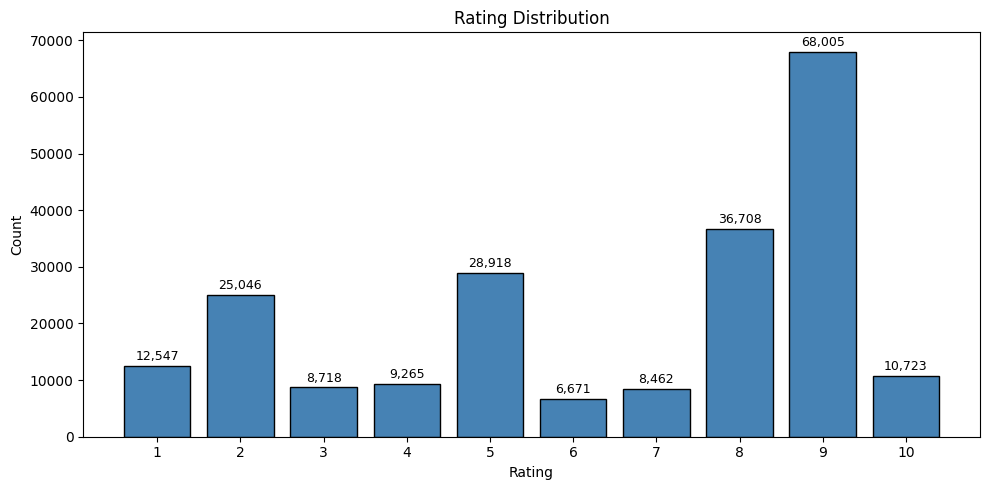

In [ ]:
# plot rating distribution
scores = dataset['rating']

plt.figure(figsize=(10, 5))
bars = plt.bar(scores.unique(), scores.value_counts(), color='steelblue', edgecolor='black')

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Distribution')

# add num samples for each val
for bar in bars: 
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.xticks(scores.unique())
plt.tight_layout()
plt.show()

#TODO: correct graph

We see that the > 7 group has a much larger representation in the dataset, so we will have to consider this when creating the train and test sets.

#### REVIEWS

Since we'll be using transformer models, we must know the lenght of the reviews:

REVIEW LENGTH (CHARACTERS)

Review character length stats:
count    215063.00
mean        458.62
std         241.00
min           3.00
25%         262.00
50%         456.00
75%         690.00
max       10787.00
Name: review_char_len, dtype: float64


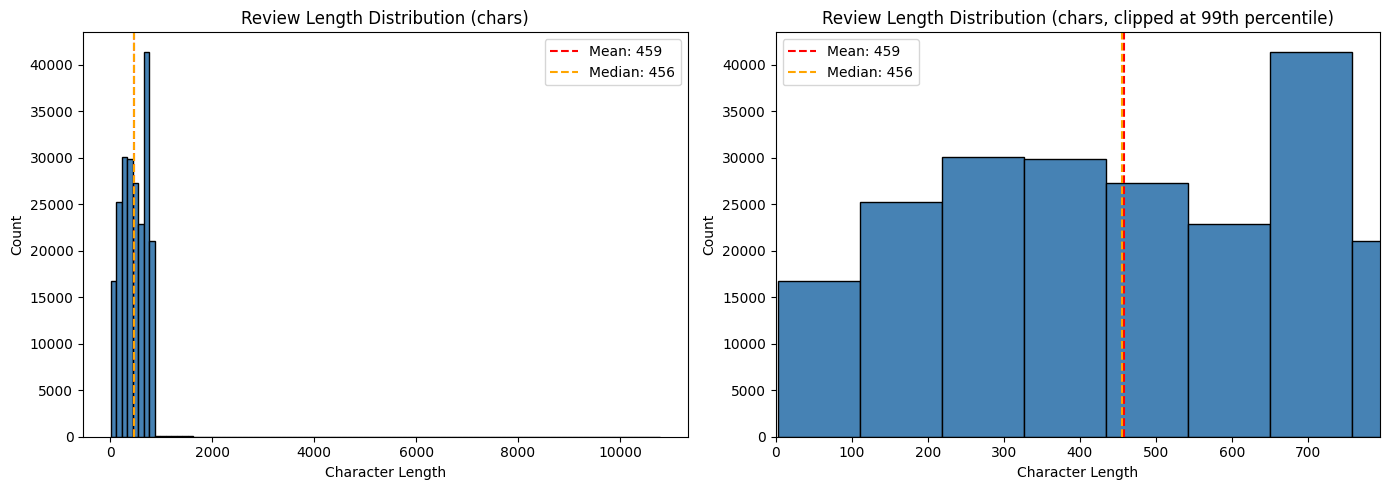

In [104]:
dataset['review_char_len'] = dataset['review'].str.len()

print("Review character length stats:")
print(dataset['review_char_len'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dataset['review_char_len'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Review Length Distribution (chars)')
axes[0].axvline(dataset['review_char_len'].mean(), color='red', linestyle='--', label=f"Mean: {dataset['review_char_len'].mean():.0f}")
axes[0].axvline(dataset['review_char_len'].median(), color='orange', linestyle='--', label=f"Median: {dataset['review_char_len'].median():.0f}")
axes[0].legend()

axes[1].hist(dataset['review_char_len'], bins=100, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Count')
axes[1].set_title('Review Length Distribution (chars, clipped at 99th percentile)')
axes[1].set_xlim(0, dataset['review_char_len'].quantile(0.99))
axes[1].axvline(dataset['review_char_len'].mean(), color='red', linestyle='--', label=f"Mean: {dataset['review_char_len'].mean():.0f}")
axes[1].axvline(dataset['review_char_len'].median(), color='orange', linestyle='--', label=f"Median: {dataset['review_char_len'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

REVIEW LENGTH (WORDS)

Review word count stats:
count    215063.00
mean         84.68
std          44.85
min           1.00
25%          48.00
50%          84.00
75%         126.00
max        1894.00
Name: review_word_count, dtype: float64


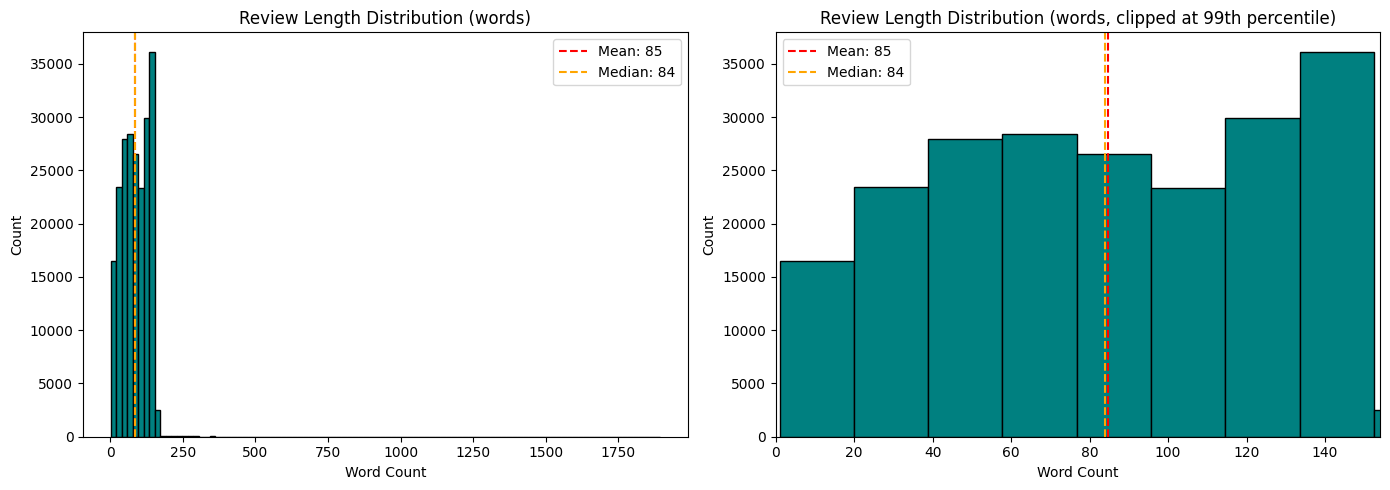

In [105]:
dataset['review_word_count'] = dataset['review'].str.split().str.len()

print("Review word count stats:")
print(dataset['review_word_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dataset['review_word_count'], bins=100, color='teal', edgecolor='black')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Count')
axes[0].set_title('Review Length Distribution (words)')
axes[0].axvline(dataset['review_word_count'].mean(), color='red', linestyle='--', label=f"Mean: {dataset['review_word_count'].mean():.0f}")
axes[0].axvline(dataset['review_word_count'].median(), color='orange', linestyle='--', label=f"Median: {dataset['review_word_count'].median():.0f}")
axes[0].legend()

axes[1].hist(dataset['review_word_count'], bins=100, color='teal', edgecolor='black')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].set_title('Review Length Distribution (words, clipped at 99th percentile)')
axes[1].set_xlim(0, dataset['review_word_count'].quantile(0.99))
axes[1].axvline(dataset['review_word_count'].mean(), color='red', linestyle='--', label=f"Mean: {dataset['review_word_count'].mean():.0f}")
axes[1].axvline(dataset['review_word_count'].median(), color='orange', linestyle='--', label=f"Median: {dataset['review_word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

A good standard conversion is 1000 tokens ~ 750 words. The base BERT model has a context window of 512 tokens, so there might be some review which connot be vecotirzed in a single pass. Depending on the model used, this will require further analysis.

REVIEW LENGTH VS RATING

C:\Users\azouh\AppData\Local\Temp\ipykernel_22212\1593145388.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(rating_groups, labels=sorted(dataset['rating'].unique()), showfliers=False)


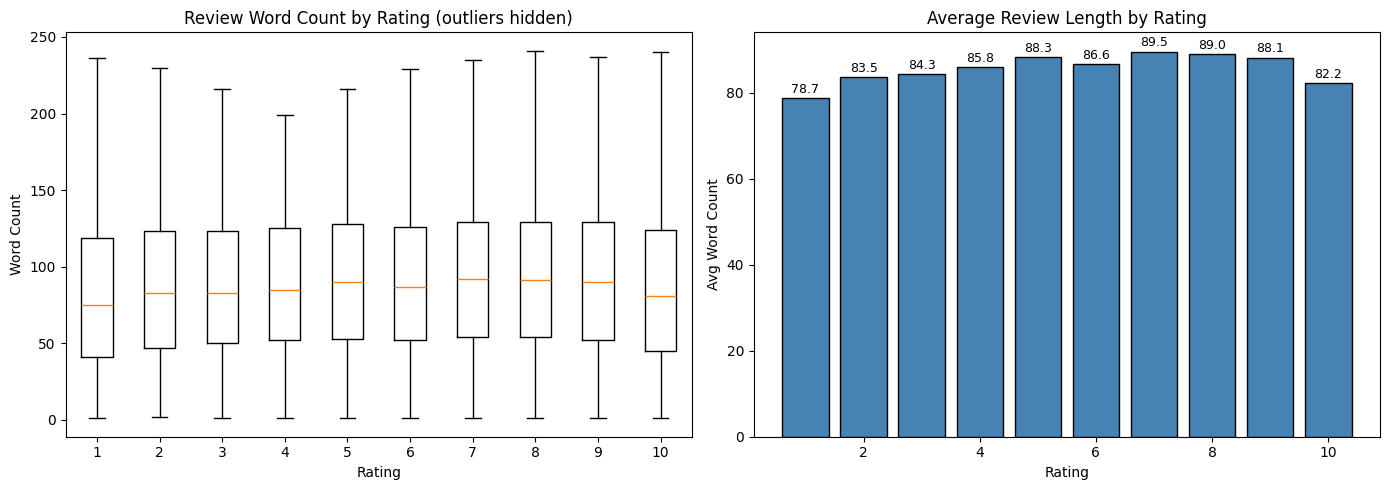


Correlation (rating vs word count): 0.0264


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_groups = [dataset[dataset['rating'] == r]['review_word_count'] for r in sorted(dataset['rating'].unique())]
axes[0].boxplot(rating_groups, labels=sorted(dataset['rating'].unique()), showfliers=False)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Word Count')
axes[0].set_title('Review Word Count by Rating (outliers hidden)')

avg_len_by_rating = dataset.groupby('rating')['review_word_count'].mean()
axes[1].bar(avg_len_by_rating.index, avg_len_by_rating.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Avg Word Count')
axes[1].set_title('Average Review Length by Rating')
for x, y in zip(avg_len_by_rating.index, avg_len_by_rating.values):
    axes[1].text(x, y + 0.5, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nCorrelation (rating vs word count): {dataset['rating'].corr(dataset['review_word_count']):.4f}")

This low correlation indicates no hidden bias for a rating lenght-wise, which is relevant to obtain comparable and usable vectors.

#### DRUGS AND CONDITIONS

TOP DRUGS & CONDITIONS

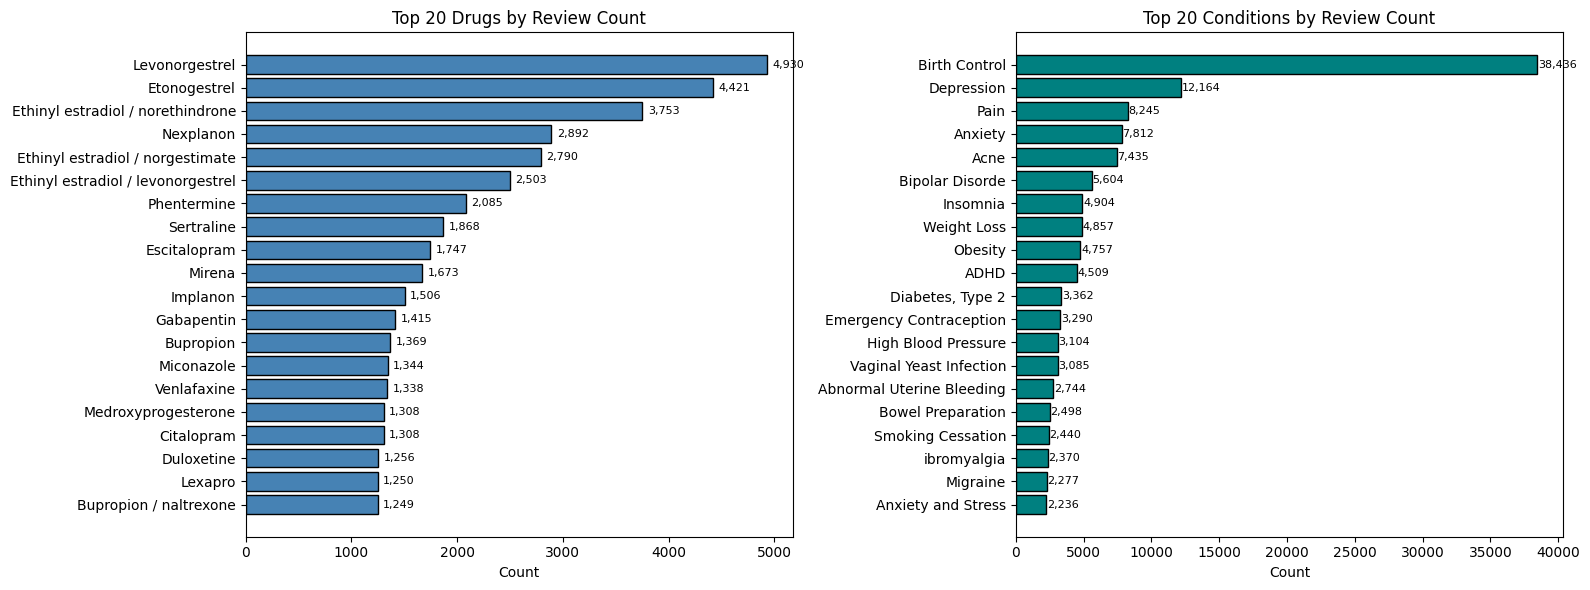


Unique drugs: 3671
Unique conditions: 916


In [107]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_drugs = dataset['drugName'].value_counts().head(20)
axes[0].barh(top_drugs.index[::-1], top_drugs.values[::-1], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 20 Drugs by Review Count')
for i, v in enumerate(top_drugs.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

top_conditions = dataset['condition'].value_counts().head(20)
axes[1].barh(top_conditions.index[::-1], top_conditions.values[::-1], color='teal', edgecolor='black')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 20 Conditions by Review Count')
for i, v in enumerate(top_conditions.values[::-1]):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nUnique drugs: {dataset['drugName'].nunique()}")
print(f"Unique conditions: {dataset['condition'].nunique()}")

DRUGS & CONDITIONS WITH ONLY 1 REVIEW

Drugs with only 1 review:      798 / 3,671 unique drugs  (21.7%)
Conditions with only 1 review: 113 / 916 unique conditions  (12.3%)


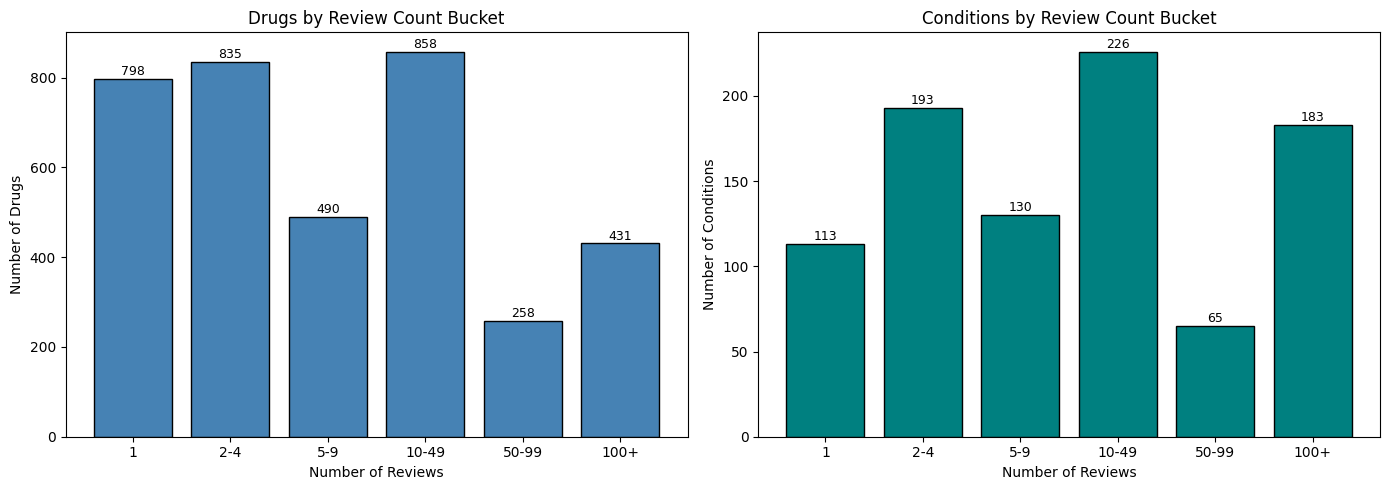


Sample drugs with only 1 review:
['Mylanta', 'Ovace Plus', 'Haldol Decanoate', 'Clinpro 5000', 'Biltricide', 'Nor-QD', 'Targiniq ER', 'Tafinlar', 'Loestrin Fe 1.5 / 30', 'Retisert']

Sample conditions with only 1 review:
['Dermatitis Herpetiformis', '94</span> users found this comment helpful.', 'Hemangioma', 'Thyroid Suppression Test', '54</span> users found this comment helpful.', 'Amyotrophic Lateral Sclerosis', '79</span> users found this comment helpful.', 'Epicondylitis, Tennis Elbow', 'Dermatitis Herpeti', 'Secondary Cutaneous Bacterial Infections']


In [108]:
single_review_drugs = dataset['drugName'].value_counts()
single_review_drugs = single_review_drugs[single_review_drugs == 1]

single_review_conditions = dataset['condition'].value_counts()
single_review_conditions = single_review_conditions[single_review_conditions == 1]

print(f"Drugs with only 1 review:      {len(single_review_drugs):,} / {dataset['drugName'].nunique():,} unique drugs  ({len(single_review_drugs)/dataset['drugName'].nunique()*100:.1f}%)")
print(f"Conditions with only 1 review: {len(single_review_conditions):,} / {dataset['condition'].nunique():,} unique conditions  ({len(single_review_conditions)/dataset['condition'].nunique()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

drug_counts = dataset['drugName'].value_counts()
review_count_bins = [1, 2, 5, 10, 50, 100, drug_counts.max()]
labels = ['1', '2-4', '5-9', '10-49', '50-99', '100+']
drug_binned = pd.cut(drug_counts, bins=review_count_bins, labels=labels, right=False)
drug_bin_counts = drug_binned.value_counts().reindex(labels)

axes[0].bar(labels, drug_bin_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Drugs')
axes[0].set_title('Drugs by Review Count Bucket')
for i, v in enumerate(drug_bin_counts.values):
    axes[0].text(i, v + 1, f'{v:,}', ha='center', va='bottom', fontsize=9)

cond_counts = dataset['condition'].value_counts()
cond_binned = pd.cut(cond_counts, bins=review_count_bins, labels=labels, right=False)
cond_bin_counts = cond_binned.value_counts().reindex(labels)

axes[1].bar(labels, cond_bin_counts.values, color='teal', edgecolor='black')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Conditions')
axes[1].set_title('Conditions by Review Count Bucket')
for i, v in enumerate(cond_bin_counts.values):
    axes[1].text(i, v + 0.5, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nSample drugs with only 1 review:")
print(single_review_drugs.index[:10].tolist())
print("\nSample conditions with only 1 review:")
print(single_review_conditions.index[:10].tolist())

There is some variance in drug and condition mentions, with some drugs being much more mentioned than other, and the birth-control being much more present in the reviews than any other condition. Additionally, some drugs and conditions have only 1 review. This difference shall be adressed further on. 

#### USEFUL COUNTS

USEFULCOUNT DISTRIBUTION

usefulCount stats:
count    215063.00
mean         28.00
std          36.35
min           0.00
25%           6.00
50%          16.00
75%          36.00
max        1291.00
Name: usefulCount, dtype: float64


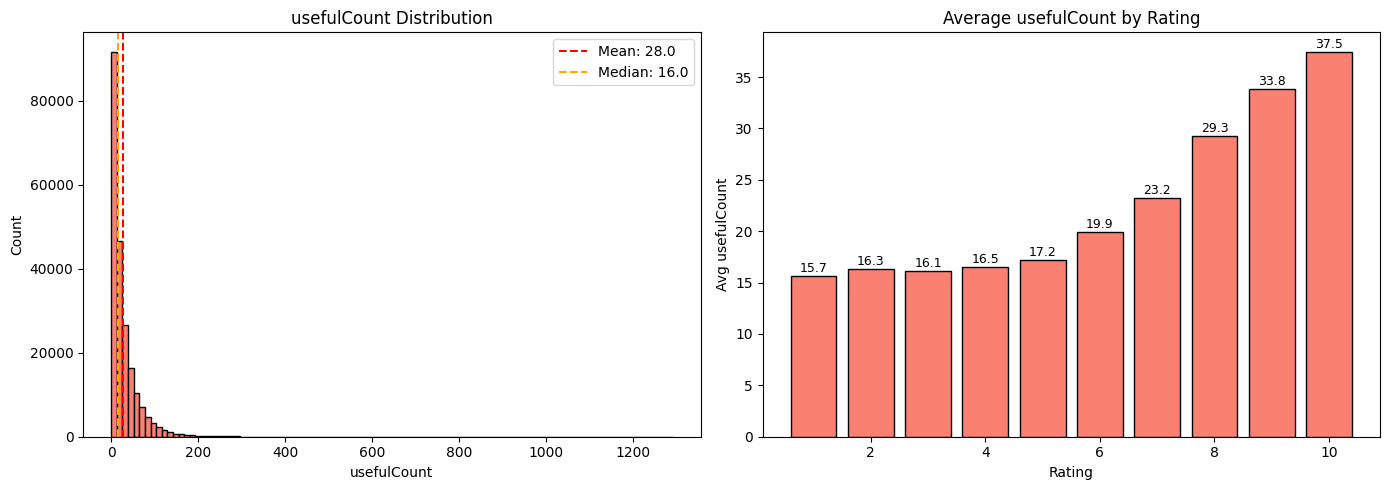


Correlation (rating vs usefulCount): 0.2349
Correlation (word count vs usefulCount): 0.0200


In [109]:
print("usefulCount stats:")
print(dataset['usefulCount'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dataset['usefulCount'], bins=100, color='salmon', edgecolor='black')
axes[0].set_xlabel('usefulCount')
axes[0].set_ylabel('Count')
axes[0].set_title('usefulCount Distribution')
axes[0].axvline(dataset['usefulCount'].mean(), color='red', linestyle='--', label=f"Mean: {dataset['usefulCount'].mean():.1f}")
axes[0].axvline(dataset['usefulCount'].median(), color='orange', linestyle='--', label=f"Median: {dataset['usefulCount'].median():.1f}")
axes[0].legend()

avg_useful_by_rating = dataset.groupby('rating')['usefulCount'].mean()
axes[1].bar(avg_useful_by_rating.index, avg_useful_by_rating.values, color='salmon', edgecolor='black')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Avg usefulCount')
axes[1].set_title('Average usefulCount by Rating')
for x, y in zip(avg_useful_by_rating.index, avg_useful_by_rating.values):
    axes[1].text(x, y + 0.1, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nCorrelation (rating vs usefulCount): {dataset['rating'].corr(dataset['usefulCount']):.4f}")
print(f"Correlation (word count vs usefulCount): {dataset['review_word_count'].corr(dataset['usefulCount']):.4f}")